In [16]:
import os
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import curve_fit
import statsmodels.api as sm
import statsmodels.formula.api as smf

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

trf_locations = sorted(
    glob.glob(
        os.path.join('experiments', '*', 'trf')
    ), key = lambda x: int(x.split(os.path.sep)[1])
)
lstm_locations = sorted(
    glob.glob(
        os.path.join('experiments', '*', 'lstm')
    ), key = lambda x: int(x.split(os.path.sep)[1])
)

markers = [
    'o', '*', 'x', '+', 's', 'D', 'p', 'h', 'v', '^'
]

MAX_LOGS = 20

In [17]:
def select_data(
    model_type = None,
    grammar_type = None,
    num_symbols = None,
    num_states_or_nts = None
):
    if model_type == 'trf':
        locs = trf_locations
    elif model_type == 'lstm':
        locs = lstm_locations
    elif model_type is None:
        locs = trf_locations + lstm_locations
        
    dfs = []
        
    for loc in locs:
        hparams = json.load(open(os.path.join(loc, 'hparams.json')))
        if grammar_type is not None and hparams['grammar_type'] != grammar_type:
            continue
        if num_symbols is not None and hparams['grammar_num_symbols'] != num_symbols:
            continue
        if num_states_or_nts is not None and hparams['grammar_formalism_arg'] != num_states_or_nts:
            continue
        dfs.append(pd.read_csv(os.path.join(loc, 'length_wise_metrics.tsv'), sep='\t'))
    
    if len(dfs) == 0:
        print('No data found')
        
    return dfs

In [18]:
def slac_plot(datas, names, by_seq=False, avg=False):
    
    if by_seq:
        plt.figure()
        
        for data_idx, (data, name) in enumerate(zip(datas, names)):
            x = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            y = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            counts = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}

            for df in data:
                for seq_len in range(1, 11):
                    subset = df[df['seq_len'] == seq_len]
                    
                    x_i = subset['step'].to_numpy()
                    y_i = subset['rho'].to_numpy()
                    
                    assert len(x_i) == len(y_i)
                    
                    if len(x_i) > MAX_LOGS:
                        x_i = x_i[:MAX_LOGS]
                        y_i = y_i[:MAX_LOGS]
                    
                    x[seq_len][:len(x_i)] += x_i
                    y[seq_len][:len(y_i)] += y_i
                    counts[seq_len][:len(x_i)] += 1

            for seq_len in range(1, 11):
                valid_mask = counts[seq_len] > 0

                plt.scatter(
                    x[seq_len][valid_mask] / counts[seq_len][valid_mask],
                    y[seq_len][valid_mask] / counts[seq_len][valid_mask],
                    label=f'{name}, len={seq_len}',
                    c=colors[seq_len-1],
                    s=6,
                    marker=markers[data_idx]
                )

        plt.grid()
        plt.title('Rho vs step by sequence length')
        plt.ylabel('Rho, grouped by sequence length')
        plt.xlabel('Training steps')
        plt.legend(loc='lower right')
        plt.show()

    if avg:
        plt.figure()
        
        for data_idx, (data, name) in enumerate(zip(datas, names)):
            x = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            y = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}
            counts = {i: np.zeros((MAX_LOGS,)) for i in range(1, 11)}

            for df in data:
                for seq_len in range(1, 11):
                    subset = df[df['seq_len'] == seq_len]
                    
                    x_i = subset['step'].to_numpy()
                    y_i = subset['rho'].to_numpy()
                    
                    assert len(x_i) == len(y_i)
                    
                    if len(x_i) > MAX_LOGS:
                        x_i = x_i[:MAX_LOGS]
                        y_i = y_i[:MAX_LOGS]
                    
                    x[seq_len][:len(x_i)] += x_i
                    y[seq_len][:len(y_i)] += y_i
                    counts[seq_len][:len(x_i)] += 1
            
            x_avg = np.zeros((MAX_LOGS,))
            y_avg = np.zeros((MAX_LOGS,))
            counts_total = np.zeros((MAX_LOGS,))

            for seq_len in range(1, 11):
                valid_mask = counts[seq_len] > 0
                x_avg[valid_mask] += x[seq_len][valid_mask] / counts[seq_len][valid_mask]
                y_avg[valid_mask] += y[seq_len][valid_mask] / counts[seq_len][valid_mask]
                counts_total[valid_mask] += 1

            # Average across sequence lengths
            valid_mask = counts_total > 0
            x_avg[valid_mask] /= counts_total[valid_mask]
            y_avg[valid_mask] /= counts_total[valid_mask]

            plt.scatter(
                x_avg[valid_mask],
                y_avg[valid_mask],
                label=name,
                s=6,
                marker=markers[data_idx]
            )

        plt.grid()
        plt.title('SLAC@(1,10)')
        plt.ylabel('Rho')
        plt.xlabel('Training steps')
        plt.legend(loc='lower right')
        plt.show()

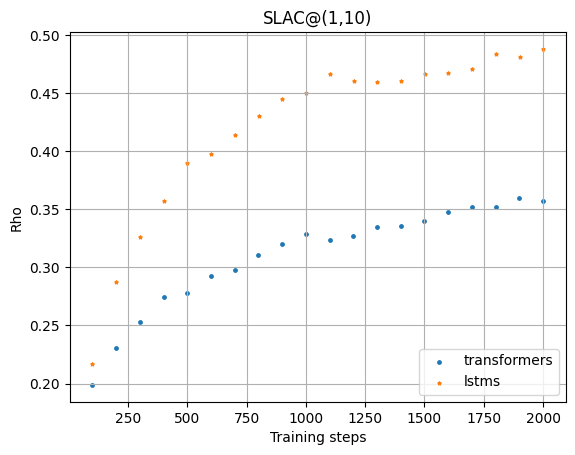

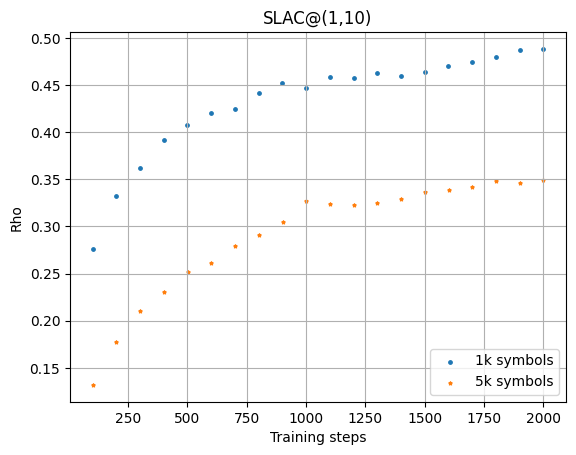

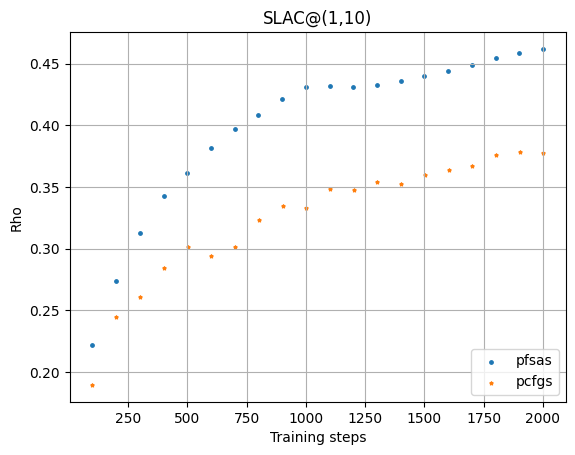

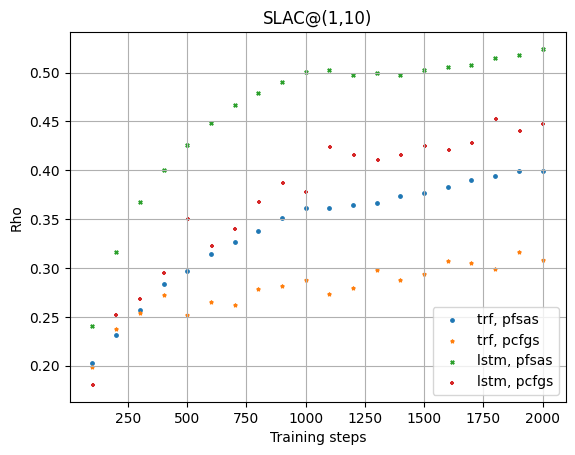

In [19]:
slac_plot(
    (select_data(model_type='trf'), select_data(model_type='lstm')), 
    ('transformers', 'lstms'), 
    avg=True
)

slac_plot(
    (select_data(num_symbols=1000), select_data(num_symbols=5000)),
    ('1k symbols', '5k symbols'),
    avg=True
)

slac_plot(
    (select_data(grammar_type='pfsa'), select_data(grammar_type='pcfg')),
    ('pfsas', 'pcfgs'),
    avg=True
)

slac_plot(
    (
        select_data(grammar_type='pfsa', model_type='trf'),
        select_data(grammar_type='pcfg', model_type='trf'),
        select_data(grammar_type='pfsa', model_type='lstm'),
        select_data(grammar_type='pcfg', model_type='lstm')
    ),
    ('trf, pfsas', 'trf, pcfgs', 'lstm, pfsas', 'lstm, pcfgs'),
    avg=True
)

In [20]:
lstm_or_trf = []
seeds = []
formalisms = []
entropy = []
train_data_ee = []
val_data_ee = []
num_symbols = []
num_states = []
max_rhos = []
max_rho_num_steps = []

k = 10

for loc in trf_locations:
    data = json.load(open(os.path.join(loc, 'hparams.json')))
    length_wise_metrics = pd.read_csv(os.path.join(loc, 'length_wise_metrics.tsv'), sep='\t')
    subset = length_wise_metrics[length_wise_metrics['seq_len'] <= k]
    means = subset.groupby('step').mean()
    means['step'] = means.index
    max_rho_at_k = means.max()['rho']
    max_rhos.append(max_rho_at_k)
    max_rho_num_steps.append(means[means['rho'] == max_rho_at_k]['step'].item())
    lstm_or_trf.append('trf')
    entropy.append(data['grammar_actual_entropy'])
    train_data_ee.append(data['train_data_ee'])
    val_data_ee.append(data['val_data_ee'])
    num_symbols.append(data['grammar_num_symbols'])
    num_states.append(data['grammar_formalism_arg'])
    seeds.append(data['grammar_seed'])
    formalisms.append(data['grammar_type'])
    
for loc in lstm_locations:
    data = json.load(open(os.path.join(loc, 'hparams.json')))
    length_wise_metrics = pd.read_csv(os.path.join(loc, 'length_wise_metrics.tsv'), sep='\t')
    subset = length_wise_metrics[length_wise_metrics['seq_len'] <= k]
    means = subset.groupby('step').mean()
    means['step'] = means.index
    max_rho_at_k = means.max()['rho']
    max_rhos.append(max_rho_at_k)
    max_rho_num_steps.append(means[means['rho'] == max_rho_at_k]['step'].item())
    lstm_or_trf.append('lstm')
    entropy.append(data['grammar_actual_entropy'])
    train_data_ee.append(data['train_data_ee'])
    val_data_ee.append(data['val_data_ee'])
    num_symbols.append(data['grammar_num_symbols'])
    num_states.append(data['grammar_formalism_arg'])
    seeds.append(data['grammar_seed'])
    formalisms.append(data['grammar_type'])
    
df = pd.DataFrame({
    'lstm_or_trf': lstm_or_trf,
    'grammar_type': formalisms,
    'seed': seeds,
    'entropy': entropy,
    'train_data_ee': train_data_ee,
    'val_data_ee': val_data_ee,
    'num_symbols': num_symbols,
    'num_states': num_states,
    'slac': max_rhos,
    'step_of_max_slac': max_rho_num_steps
})

In [21]:
# regressions
# predict SLAC or correlation coeffs from entropy, vocab size, num states, model type, grammar type

model = smf.mixedlm(
    'slac ~ num_symbols + num_states + lstm_or_trf + entropy + grammar_type',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     142        Method:                REML   
No. Groups:           3          Scale:                 0.0172 
Min. group size:      46         Log-Likelihood:        54.2870
Max. group size:      48         Converged:             Yes    
Mean group size:      47.3                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.558    0.029 19.596 0.000  0.503  0.614
lstm_or_trf[T.trf]   -0.057    0.022 -2.593 0.010 -0.100 -0.014
grammar_type[T.pfsa]  0.133    0.022  5.910 0.000  0.089  0.176
num_symbols          -0.000    0.000 -5.894 0.000 -0.000 -0.000
num_states           -0.003    0.000 -6.806 0.000 -0.004 -0.002
entropy              -0.000    0.000 -7.048 0.000 -0.001 -0.000
Group Var             0.000                                    
===============================================================

"""

In [22]:
# separate regressions broken down by model type, grammar type, vocab size, num states

subset = df[df['lstm_or_trf'] == 'trf']

model = smf.mixedlm(
    'slac ~ num_symbols + num_states + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     71         Method:                REML   
No. Groups:           3          Scale:                 0.0150 
Min. group size:      23         Log-Likelihood:        19.5605
Max. group size:      24         Converged:             Yes    
Mean group size:      23.7                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.548    0.035 15.555 0.000  0.479  0.617
grammar_type[T.pfsa]  0.087    0.030  2.938 0.003  0.029  0.145
num_symbols          -0.000    0.000 -4.053 0.000 -0.000 -0.000
num_states           -0.005    0.001 -7.188 0.000 -0.006 -0.004
entropy              -0.000    0.000 -1.955 0.051 -0.001  0.000
Group Var             0.000    0.030                           
===============================================================

"""

In [23]:
subset = df[df['lstm_or_trf'] == 'lstm']

model = smf.mixedlm(
    'slac ~ num_symbols + num_states + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.1

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     71         Method:                REML   
No. Groups:           3          Scale:                 0.0165 
Min. group size:      23         Log-Likelihood:        16.2864
Max. group size:      24         Converged:             No     
Mean group size:      23.7                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.512    0.037 13.955 0.000  0.440  0.584
grammar_type[T.pfsa]  0.178    0.031  5.729 0.000  0.117  0.239
num_symbols          -0.000    0.000 -4.650 0.000 -0.000 -0.000
num_states           -0.002    0.001 -2.759 0.006 -0.003 -0.001
entropy              -0.001    0.000 -4.302 0.000 -0.001 -0.000
Group Var             0.000                                    
===============================================================

"""

In [24]:
subset = df[df['grammar_type'] == 'pfsa']

model = smf.mixedlm(
    'slac ~ num_symbols + num_states + lstm_or_trf + entropy',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:                MixedLM   Dependent Variable:   slac   
No. Observations:     72        Method:               REML   
No. Groups:           3         Scale:                0.0035 
Min. group size:      24        Log-Likelihood:       74.7272
Max. group size:      24        Converged:            No     
Mean group size:      24.0                                   
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           1.668    0.132 12.610 0.000  1.409  1.928
lstm_or_trf[T.trf] -0.095    0.014 -6.821 0.000 -0.122 -0.068
num_symbols         0.000    0.000  1.111 0.267 -0.000  0.000
num_states         -0.002    0.001 -2.527 0.012 -0.004 -0.000
entropy            -0.114    0.017 -6.625 0.000 -0.148 -0.080
Group Var           0.000                                    
=============================================================

"""

In [25]:
subset = df[df['grammar_type'] == 'pcfg']

model = smf.mixedlm(
    'slac ~ num_symbols + num_states + lstm_or_trf + entropy',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:                MixedLM   Dependent Variable:   slac   
No. Observations:     70        Method:               REML   
No. Groups:           3         Scale:                0.0135 
Min. group size:      22        Log-Likelihood:       21.6435
Max. group size:      24        Converged:            Yes    
Mean group size:      23.3                                   
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.443    0.035 12.784 0.000  0.375  0.511
lstm_or_trf[T.trf] -0.018    0.028 -0.656 0.512 -0.073  0.036
num_symbols        -0.000    0.000 -3.978 0.000 -0.000 -0.000
num_states          0.001    0.001  0.849 0.396 -0.001  0.002
entropy            -0.000    0.000 -4.448 0.000 -0.001 -0.000
Group Var           0.000    0.007                           
=============================================================

"""

In [26]:
subset = df[df['num_symbols'] == 1000]

model = smf.mixedlm(
    'slac ~ num_states + lstm_or_trf + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     70         Method:                REML   
No. Groups:           3          Scale:                 0.0120 
Min. group size:      22         Log-Likelihood:        33.9743
Max. group size:      24         Converged:             Yes    
Mean group size:      23.3                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.545    0.027 20.053 0.000  0.492  0.599
lstm_or_trf[T.trf]   -0.080    0.026 -3.050 0.002 -0.131 -0.029
grammar_type[T.pfsa]  0.157    0.028  5.698 0.000  0.103  0.211
num_states           -0.005    0.001 -7.502 0.000 -0.006 -0.003
entropy              -0.001    0.000 -6.180 0.000 -0.001 -0.000
Group Var             0.000    0.006                           
===============================================================

"""

In [27]:
subset = df[df['num_symbols'] == 5000]

model = smf.mixedlm(
    'slac ~ num_states + lstm_or_trf + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     72         Method:                REML   
No. Groups:           3          Scale:                 0.0125 
Min. group size:      24         Log-Likelihood:        36.6199
Max. group size:      24         Converged:             Yes    
Mean group size:      24.0                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.313    0.027 11.485 0.000  0.259  0.366
lstm_or_trf[T.trf]   -0.035    0.026 -1.320 0.187 -0.086  0.017
grammar_type[T.pfsa]  0.186    0.028  6.621 0.000  0.131  0.241
num_states           -0.006    0.001 -7.454 0.000 -0.008 -0.004
entropy               0.006    0.001  6.449 0.000  0.004  0.007
Group Var             0.000                                    
===============================================================

"""

In [28]:
subset = df[df['num_states'] == 2]

model = smf.mixedlm(
    'slac ~ num_symbols + lstm_or_trf + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     22         Method:                REML   
No. Groups:           3          Scale:                 0.0045 
Min. group size:      6          Log-Likelihood:        10.8947
Max. group size:      8          Converged:             Yes    
Mean group size:      7.3                                      
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -1.352    2.297 -0.589 0.556 -5.853  3.150
lstm_or_trf[T.trf]    0.112    0.029  3.898 0.000  0.056  0.168
grammar_type[T.pfsa]  0.002    0.395  0.005 0.996 -0.772  0.776
num_symbols          -0.000    0.000 -0.959 0.338 -0.000  0.000
entropy               0.287    0.375  0.765 0.444 -0.449  1.023
Group Var             0.000    0.021                           
===============================================================

"""

In [29]:
subset = df[df['num_states'] == 4]

model = smf.mixedlm(
    'slac ~ num_symbols + lstm_or_trf + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                 MixedLM    Dependent Variable:    slac  
No. Observations:      24         Method:                REML  
No. Groups:            3          Scale:                 0.0058
Min. group size:       8          Log-Likelihood:        9.7092
Max. group size:       8          Converged:             Yes   
Mean group size:       8.0                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             1.742    0.689  2.528 0.011  0.392  3.093
lstm_or_trf[T.trf]    0.054    0.031  1.744 0.081 -0.007  0.116
grammar_type[T.pfsa]  0.661    0.163  4.063 0.000  0.342  0.980
num_symbols           0.000    0.000  1.114 0.265 -0.000  0.000
entropy              -0.219    0.110 -1.992 0.046 -0.434 -0.004
Group Var             0.000                                    
===============================================================

"""

In [30]:
subset = df[df['num_states'] == 8]

model = smf.mixedlm(
    'slac ~ num_symbols + lstm_or_trf + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     24         Method:                REML   
No. Groups:           3          Scale:                 0.0051 
Min. group size:      8          Log-Likelihood:        10.0658
Max. group size:      8          Converged:             No     
Mean group size:      8.0                                      
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.737    0.468  1.575 0.115 -0.180  1.655
lstm_or_trf[T.trf]   -0.080    0.029 -2.741 0.006 -0.137 -0.023
grammar_type[T.pfsa]  0.288    0.115  2.511 0.012  0.063  0.513
num_symbols          -0.000    0.000 -1.669 0.095 -0.000  0.000
entropy              -0.031    0.068 -0.459 0.646 -0.165  0.102
Group Var             0.000    0.016                           
===============================================================

"""

In [31]:
subset = df[df['num_states'] == 16]

model = smf.mixedlm(
    'slac ~ num_symbols + lstm_or_trf + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                 MixedLM    Dependent Variable:    slac  
No. Observations:      24         Method:                REML  
No. Groups:            3          Scale:                 0.0064
Min. group size:       8          Log-Likelihood:        6.0772
Max. group size:       8          Converged:             Yes   
Mean group size:       8.0                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.613    0.177  3.454 0.001  0.265  0.960
lstm_or_trf[T.trf]   -0.126    0.033 -3.885 0.000 -0.190 -0.063
grammar_type[T.pfsa]  0.086    0.033  2.647 0.008  0.022  0.150
num_symbols          -0.000    0.000 -5.480 0.000 -0.000 -0.000
entropy              -0.003    0.017 -0.208 0.835 -0.036  0.030
Group Var             0.001    0.026                           
===============================================================

"""

In [32]:
subset = df[df['num_states'] == 32]

model = smf.mixedlm(
    'slac ~ num_symbols + lstm_or_trf + entropy + grammar_type',
    groups=subset['seed'],
    data=subset
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                 MixedLM    Dependent Variable:    slac  
No. Observations:      24         Method:                REML  
No. Groups:            3          Scale:                 0.0038
Min. group size:       8          Log-Likelihood:        5.8892
Max. group size:       8          Converged:             Yes   
Mean group size:       8.0                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.614    0.049 12.641 0.000  0.519  0.709
lstm_or_trf[T.trf]   -0.164    0.025 -6.501 0.000 -0.214 -0.115
grammar_type[T.pfsa] -0.041    0.033 -1.237 0.216 -0.106  0.024
num_symbols          -0.000    0.000 -5.910 0.000 -0.000 -0.000
entropy              -0.000    0.000 -4.183 0.000 -0.000 -0.000
Group Var             0.000    0.017                           
===============================================================

"""

In [33]:
# predictors in isolation

model = smf.mixedlm(
    'slac ~ num_symbols',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python

<class 'statsmodels.iolib.summary2.Summary'>
"""
        Mixed Linear Model Regression Results
======================================================
Model:             MixedLM Dependent Variable: slac   
No. Observations:  142     Method:             REML   
No. Groups:        3       Scale:              0.0284 
Min. group size:   46      Log-Likelihood:     38.0049
Max. group size:   48      Converged:          No     
Mean group size:   47.3                               
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    0.548    0.026 21.321 0.000  0.497  0.598
num_symbols -0.000    0.000 -5.551 0.000 -0.000 -0.000
Group Var    0.000                                    
======================================================

"""

In [34]:
model = smf.mixedlm(
    'slac ~ num_states',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
        Mixed Linear Model Regression Results
=====================================================
Model:            MixedLM Dependent Variable: slac   
No. Observations: 142     Method:             REML   
No. Groups:       3       Scale:              0.0296 
Min. group size:  46      Log-Likelihood:     39.7622
Max. group size:  48      Converged:          Yes    
Mean group size:  47.3                               
-----------------------------------------------------
           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------
Intercept   0.498    0.020 24.634 0.000  0.459  0.538
num_states -0.003    0.001 -4.919 0.000 -0.005 -0.002
Group Var   0.000                                    
=====================================================

"""

In [35]:
model = smf.mixedlm(
    'slac ~ lstm_or_trf',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:                MixedLM   Dependent Variable:   slac   
No. Observations:     142       Method:               REML   
No. Groups:           3         Scale:                0.0339 
Min. group size:      46        Log-Likelihood:       34.0645
Max. group size:      48        Converged:            Yes    
Mean group size:      47.3                                   
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.457    0.022 20.940 0.000  0.414  0.500
lstm_or_trf[T.trf] -0.057    0.031 -1.848 0.065 -0.118  0.003
Group Var           0.000                                    
=============================================================

"""

In [36]:
model = smf.mixedlm(
    'slac ~ entropy',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python

<class 'statsmodels.iolib.summary2.Summary'>
"""
        Mixed Linear Model Regression Results
=====================================================
Model:            MixedLM Dependent Variable: slac   
No. Observations: 142     Method:             REML   
No. Groups:       3       Scale:              0.0322 
Min. group size:  46      Log-Likelihood:     32.1592
Max. group size:  48      Converged:          No     
Mean group size:  47.3                               
-----------------------------------------------------
           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------
Intercept   0.424    0.015 28.009 0.000  0.394  0.453
entropy    -0.000    0.000 -3.330 0.001 -0.001 -0.000
Group Var   0.000                                    
=====================================================

"""

In [37]:
model = smf.mixedlm(
    'slac ~ grammar_type',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:               MixedLM    Dependent Variable:    slac   
No. Observations:    142        Method:                REML   
No. Groups:          3          Scale:                 0.0311 
Min. group size:     46         Log-Likelihood:        39.9125
Max. group size:     48         Converged:             Yes    
Mean group size:     47.3                                     
--------------------------------------------------------------
                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.369    0.021 17.485 0.000  0.327  0.410
grammar_type[T.pfsa] 0.118    0.030  3.989 0.000  0.060  0.176
Group Var            0.000                                    
==============================================================

"""

In [38]:
# hold-one-out regressions

model = smf.mixedlm(
    'slac ~ num_states + lstm_or_trf + entropy + grammar_type',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     142        Method:                REML   
No. Groups:           3          Scale:                 0.0215 
Min. group size:      46         Log-Likelihood:        49.8694
Max. group size:      48         Converged:             Yes    
Mean group size:      47.3                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.452    0.025 18.215 0.000  0.403  0.500
lstm_or_trf[T.trf]   -0.057    0.025 -2.322 0.020 -0.105 -0.009
grammar_type[T.pfsa]  0.140    0.025  5.612 0.000  0.091  0.189
num_states           -0.003    0.001 -5.980 0.000 -0.005 -0.002
entropy              -0.001    0.000 -5.375 0.000 -0.001 -0.000
Group Var             0.000                                    
===============================================================

"""

In [39]:
model = smf.mixedlm(
    'slac ~ num_symbols + lstm_or_trf + entropy + grammar_type',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     142        Method:                REML   
No. Groups:           3          Scale:                 0.0227 
Min. group size:      46         Log-Likelihood:        41.5416
Max. group size:      48         Converged:             No     
Mean group size:      47.3                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.486    0.030 15.951 0.000  0.427  0.546
lstm_or_trf[T.trf]   -0.057    0.025 -2.258 0.024 -0.107 -0.008
grammar_type[T.pfsa]  0.133    0.026  5.165 0.000  0.083  0.183
num_symbols          -0.000    0.000 -5.130 0.000 -0.000 -0.000
entropy              -0.000    0.000 -3.521 0.000 -0.001 -0.000
Group Var             0.000                                    
===============================================================

"""

In [40]:
model = smf.mixedlm(
    'slac ~ num_symbols + num_states + entropy + grammar_type',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     142        Method:                REML   
No. Groups:           3          Scale:                 0.0179 
Min. group size:      46         Log-Likelihood:        53.8814
Max. group size:      48         Converged:             Yes    
Mean group size:      47.3                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.530    0.027 19.634 0.000  0.477  0.583
grammar_type[T.pfsa]  0.133    0.023  5.789 0.000  0.088  0.177
num_symbols          -0.000    0.000 -5.774 0.000 -0.000 -0.000
num_states           -0.003    0.001 -6.560 0.000 -0.004 -0.002
entropy              -0.000    0.000 -4.493 0.000 -0.001 -0.000
Group Var             0.000                                    
===============================================================

"""

In [41]:
model = smf.mixedlm(
    'slac ~ num_symbols + num_states + lstm_or_trf + grammar_type',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM    Dependent Variable:    slac   
No. Observations:     142        Method:                REML   
No. Groups:           3          Scale:                 0.0195 
Min. group size:      46         Log-Likelihood:        53.7520
Max. group size:      48         Converged:             Yes    
Mean group size:      47.3                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.588    0.030 19.881 0.000  0.530  0.646
lstm_or_trf[T.trf]   -0.057    0.023 -2.438 0.015 -0.103 -0.011
grammar_type[T.pfsa]  0.114    0.023  4.874 0.000  0.068  0.160
num_symbols          -0.000    0.000 -6.715 0.000 -0.000 -0.000
num_states           -0.003    0.001 -6.086 0.000 -0.004 -0.002
Group Var             0.000                                    
===============================================================

"""

In [42]:
model = smf.mixedlm(
    'slac ~ num_symbols + num_states + lstm_or_trf + entropy',
    groups=df['seed'],
    data=df
)
res = model.fit()
res.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:                MixedLM   Dependent Variable:   slac   
No. Observations:     142       Method:               REML   
No. Groups:           3         Scale:                0.0215 
Min. group size:      46        Log-Likelihood:       41.5194
Max. group size:      48        Converged:            Yes    
Mean group size:      47.3                                   
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.633    0.029 22.029 0.000  0.577  0.689
lstm_or_trf[T.trf] -0.057    0.025 -2.321 0.020 -0.105 -0.009
num_symbols        -0.000    0.000 -5.597 0.000 -0.000 -0.000
num_states         -0.003    0.001 -5.999 0.000 -0.005 -0.002
entropy            -0.000    0.000 -2.986 0.003 -0.000 -0.000
Group Var           0.000                                    
=============================================================

"""